In [41]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename) — values must be borough labels, not paths alone
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)

    print(f"Shape of {borough} data: {df.shape}")

    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"].notna()]
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"] > 0]

sales = pd.concat(borough_frames.values(), ignore_index=True)

sales.shape, list(borough_frames.keys())

Shape of Bronx data: (6498, 21)
Shape of Brooklyn data: (22641, 21)
Shape of Manhattan data: (19163, 21)
Shape of Queens data: (26385, 21)
Shape of Staten Island data: (7036, 21)


((53956, 21), ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'])

In [ ]:
# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass  # column already absent in this frame

In [44]:

# How empty is each column in each borough?
def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

for borough in borough_frames:
    print(f"Percentage of empty values in {borough} data:")
    for col in borough_frames[borough].columns:
        pct = is_nullish(borough_frames[borough][col]).mean()
        print(f"{col}: {pct}")
    print()

Percentage of empty values in Bronx data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.22034296452901103
COMMERCIAL UNITS: 0.22034296452901103
TOTAL UNITS: 0.22034296452901103
LAND SQUARE FEET: 0.30913789053323937
GROSS SQUARE FEET: 0.30913789053323937
YEAR BUILT: 0.09701667841202725
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0

Percentage of empty values in Brooklyn data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 7.126060001425212e-05
RESIDENTIAL UNITS: 0.16183282263236656
COMMERCIAL UNITS: 0.16183282263236656
TOTAL UNITS: 0.16183282263236656
LAND SQUARE FEET: 0.45934582769186916
GROSS SQUARE FEET: 0.45934582769186916
YEAR BUILT: 0.06719874581343975
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF

In [45]:
# Work with manhattan coops (exclude categories that also contain CONDO, e.g. CONDO COOPS)
_bcc = borough_frames["Manhattan"]["BUILDING CLASS CATEGORY"].astype(str).str.upper()
manhattan_coops = borough_frames["Manhattan"][_bcc.str.contains("COOP") & ~_bcc.str.contains("CONDO")]

# Total number of rentals
print("Total number of rentals:")
print(manhattan_coops.shape[0])

# See what different Building class categories are there
print("Building class categories:")
print(manhattan_coops["BUILDING CLASS CATEGORY"].unique())

# see the columns one more time
print(manhattan_coops.columns)

Total number of rentals:
6075
Building class categories:
<StringArray>
['09 COOPS - WALKUP APARTMENTS', '10 COOPS - ELEVATOR APARTMENTS']
Length: 2, dtype: str
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')


In [46]:
# print the head
print(manhattan_coops.head())

     NEIGHBORHOOD       BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  BLOCK  \
17  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    372   
18  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    373   
19  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    373   
20  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                   2C    374   
21  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    375   

    LOT BUILDING CLASS AT PRESENT                  ADDRESS  ZIP CODE  \
17   55                        C6         290 2 STREET, 2D     10009   
18   40                        C6  327 EAST 3RD STREET, 2A     10009   
19   46                        C6   317 EAST 3RD STREET, 8     10009   
20    8                        C6     702 E 5TH STREET, 5E     10009   
21   30                        C6    742 EAST 6 STREET, 13     10009   

    RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS  LAND SQUARE FEET  \
17                

In [47]:
# Print the columsn that are entirely null
print(manhattan_coops.columns[manhattan_coops.isna().all()])

# remove any columsn that are entirely null
manhattan_coops = manhattan_coops.dropna(axis=1, how="all")

# print the head
print(manhattan_coops.head())

Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET'],
      dtype='str')
     NEIGHBORHOOD       BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  BLOCK  \
17  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    372   
18  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    373   
19  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    373   
20  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                   2C    374   
21  ALPHABET CITY  09 COOPS - WALKUP APARTMENTS                    2    375   

    LOT BUILDING CLASS AT PRESENT                  ADDRESS  ZIP CODE  \
17   55                        C6         290 2 STREET, 2D     10009   
18   40                        C6  327 EAST 3RD STREET, 2A     10009   
19   46                        C6   317 EAST 3RD STREET, 8     10009   
20    8                        C6     702 E 5TH STREET, 5E     10009   
21   30                        C6 

In [48]:
# print out what percent of each column is null
for col in manhattan_coops.columns:
    print(f"{col}: {manhattan_coops[col].isna().mean()}")


NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
YEAR BUILT: 0.0
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0


In [49]:
# drop tax class at time of sale, create age of the building (and drop the year built column), remoc building class category, remove address
manhattan_coops = manhattan_coops.drop(columns=["TAX CLASS AT TIME OF SALE"])
manhattan_coops["AGE OF THE BUILDING"] = 2026 - manhattan_coops["YEAR BUILT"]
manhattan_coops = manhattan_coops.drop(columns=["BUILDING CLASS CATEGORY"])
manhattan_coops = manhattan_coops.drop(columns=["ADDRESS"])

# print the head
print(manhattan_coops.head())

     NEIGHBORHOOD TAX CLASS AT PRESENT  BLOCK  LOT BUILDING CLASS AT PRESENT  \
17  ALPHABET CITY                    2    372   55                        C6   
18  ALPHABET CITY                    2    373   40                        C6   
19  ALPHABET CITY                    2    373   46                        C6   
20  ALPHABET CITY                   2C    374    8                        C6   
21  ALPHABET CITY                    2    375   30                        C6   

    ZIP CODE  YEAR BUILT BUILDING CLASS AT TIME OF SALE  SALE PRICE  \
17     10009      1920.0                             C6      655000   
18     10009      1920.0                             C6      580000   
19     10009      1925.0                             C6      474000   
20     10009      1900.0                             C6     1200000   
21     10009      1902.0                             C6      330000   

    SALE DATE  AGE OF THE BUILDING  
17 2025-10-29                106.0  
18 2026-02-12     

In [50]:
# remove outliers in Sale price (using IQR)
q1 = manhattan_coops["SALE PRICE"].quantile(0.25)
q3 = manhattan_coops["SALE PRICE"].quantile(0.75)
iqr = q3 - q1

# print the percentalge of outliers
print(f"Percentage of outliers: {(manhattan_coops["SALE PRICE"] > q3 + 1.5 * iqr).mean()}")

manhattan_coops = manhattan_coops[manhattan_coops["SALE PRICE"] < q3 + 1.5 * iqr]


# print the head
print(manhattan_coops.head())

Percentage of outliers: 0.08345679012345679
     NEIGHBORHOOD TAX CLASS AT PRESENT  BLOCK  LOT BUILDING CLASS AT PRESENT  \
17  ALPHABET CITY                    2    372   55                        C6   
18  ALPHABET CITY                    2    373   40                        C6   
19  ALPHABET CITY                    2    373   46                        C6   
20  ALPHABET CITY                   2C    374    8                        C6   
21  ALPHABET CITY                    2    375   30                        C6   

    ZIP CODE  YEAR BUILT BUILDING CLASS AT TIME OF SALE  SALE PRICE  \
17     10009      1920.0                             C6      655000   
18     10009      1920.0                             C6      580000   
19     10009      1925.0                             C6      474000   
20     10009      1900.0                             C6     1200000   
21     10009      1902.0                             C6      330000   

    SALE DATE  AGE OF THE BUILDING  
17 2025-10-

In [51]:
# Time & place: walkup vs elevator, neighborhood, vintage (rebuilt from Manhattan so we keep BCC)
REF_YEAR = 2026

m = borough_frames["Manhattan"].copy()
_bcc = m["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp = m[_bcc.str.contains("COOP") & ~_bcc.str.contains("CONDO")].copy()

coop_tp["SALE DATE"] = pd.to_datetime(coop_tp["SALE DATE"])
bcc_upper = coop_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp["COOP_TYPE"] = np.where(
    bcc_upper.str.contains("WALKUP"),
    "Walkup",
    np.where(bcc_upper.str.contains("ELEVATOR"), "Elevator", "Other"),
)

coop_tp["YEAR BUILT"] = pd.to_numeric(coop_tp["YEAR BUILT"], errors="coerce")
coop_tp["BUILDING_AGE"] = REF_YEAR - coop_tp["YEAR BUILT"]

# Match earlier notebook: upper-tail IQR trim on sale price (coop slice)
q1 = coop_tp["SALE PRICE"].quantile(0.25)
q3 = coop_tp["SALE PRICE"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
coop_tp = coop_tp[coop_tp["SALE PRICE"] < upper_fence].copy()

coop_tp["YEAR"] = coop_tp["SALE DATE"].dt.year
coop_tp["MONTH"] = coop_tp["SALE DATE"].dt.month
coop_tp["YEAR_MONTH"] = coop_tp["SALE DATE"].dt.to_period("M")
coop_tp["QUARTER"] = coop_tp["SALE DATE"].dt.to_period("Q")

print("COOP_TYPE counts:\n", coop_tp["COOP_TYPE"].value_counts(), sep="")
print(f"\nRows after upper IQR trim: {len(coop_tp):,}")
print(
    f"Sale date range: {coop_tp['SALE DATE'].min().date()} – {coop_tp['SALE DATE'].max().date()}"
)
print(f"Neighborhoods: {coop_tp['NEIGHBORHOOD'].nunique()}")


COOP_TYPE counts:
COOP_TYPE
Elevator    4906
Walkup       659
Name: count, dtype: int64

Rows after upper IQR trim: 5,565
Sale date range: 2025-03-03 – 2026-02-27
Neighborhoods: 39


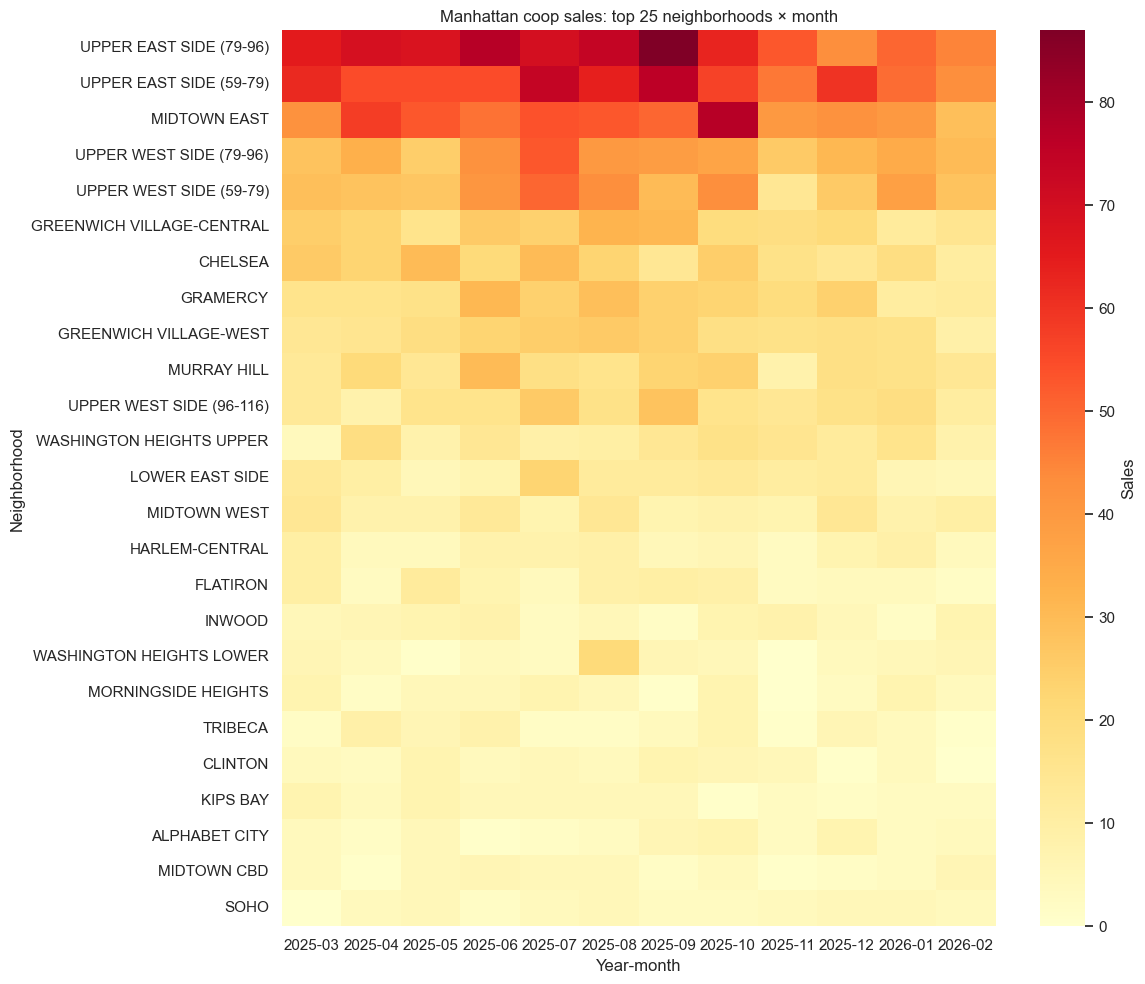

Peak year-month per neighborhood (top 25 by volume) and share of that hood’s sales in that month:
                          peak_year_month  share_of_nbhd_in_peak_month
NEIGHBORHOOD                                                          
WASHINGTON HEIGHTS LOWER          2025-08                     0.323077
LOWER EAST SIDE                   2025-07                     0.178295
TRIBECA                           2025-04                     0.173077
FLATIRON                          2025-05                     0.155844
ALPHABET CITY                     2025-10                     0.148936
CLINTON                           2025-09                     0.140000
KIPS BAY                          2025-05                     0.140000
UPPER WEST SIDE (96-116)          2025-09                     0.139303
MURRAY HILL                       2025-06                     0.138889
MIDTOWN CBD                       2025-06                     0.136364
MORNINGSIDE HEIGHTS               2026-01         

In [52]:
# Where and when are sales concentrated? (top neighborhoods × month)
sns.set_theme(style="whitegrid")
TOP_N_NBHD = 25

n_by_nbhd = coop_tp.groupby("NEIGHBORHOOD").size().sort_values(ascending=False)
top_nbhds = n_by_nbhd.head(TOP_N_NBHD).index

vol_ym = (
    coop_tp.loc[coop_tp["NEIGHBORHOOD"].isin(top_nbhds)]
    .groupby(["NEIGHBORHOOD", "YEAR_MONTH"], observed=True)
    .size()
    .unstack(fill_value=0)
)
vol_ym = vol_ym.loc[n_by_nbhd.head(TOP_N_NBHD).index]
vol_ym.columns = vol_ym.columns.astype(str)

fig, ax = plt.subplots(figsize=(max(12, vol_ym.shape[1] * 0.35), 10))
sns.heatmap(vol_ym, cmap="YlOrRd", ax=ax, linewidths=0, cbar_kws={"label": "Sales"})
ax.set_title("Manhattan coop sales: top 25 neighborhoods × month")
ax.set_xlabel("Year-month")
ax.set_ylabel("Neighborhood")
plt.tight_layout()
plt.show()

# Modal (most common) sale month per top neighborhood — "when is this area busiest?"
peak_month = (
    coop_tp.loc[coop_tp["NEIGHBORHOOD"].isin(top_nbhds)]
    .groupby("NEIGHBORHOOD", observed=True)["YEAR_MONTH"]
    .agg(lambda s: s.astype(str).value_counts().idxmax())
    .rename("peak_year_month")
)
share_peak = (
    coop_tp.loc[coop_tp["NEIGHBORHOOD"].isin(top_nbhds)]
    .groupby(["NEIGHBORHOOD", "YEAR_MONTH"], observed=True)
    .size()
    .groupby(level=0)
    .apply(lambda s: s.max() / s.sum())
    .rename("share_of_nbhd_in_peak_month")
)
peak_tbl = pd.concat([peak_month, share_peak], axis=1).sort_values("share_of_nbhd_in_peak_month", ascending=False)
print("Peak year-month per neighborhood (top 25 by volume) and share of that hood’s sales in that month:")
print(peak_tbl.to_string())


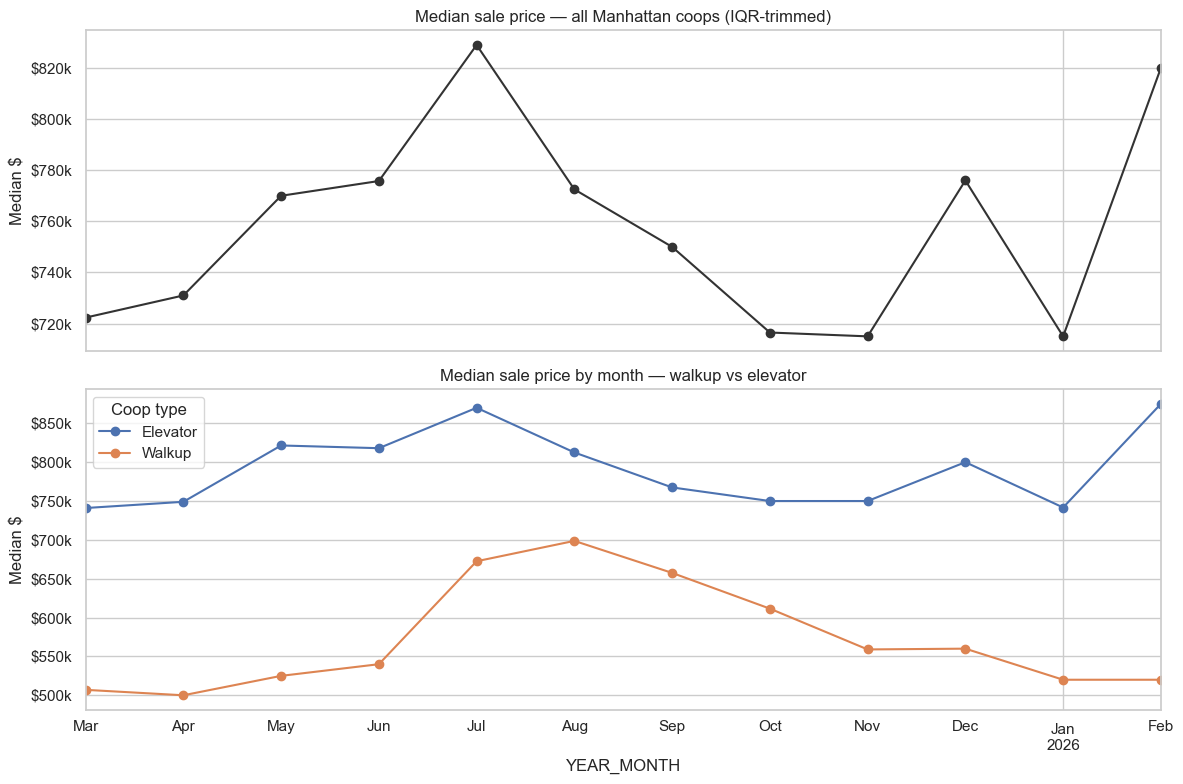

Calendar month (pooled across years): count and median price — higher median ≈ pricier time of year in this sample
              n  median_price
month_name                   
July        559      829000.0
February    327      820000.0
December    425      776000.0
June        522      775777.5
August      553      772500.0
May         449      770000.0
September   537      750000.0
April       448      731000.0
March       446      722337.5
October     532      716500.0
January     413      715000.0
November    354      715000.0


In [53]:
# Median prices over time — overall, by walkup vs elevator, and seasonality (calendar month)
med_all = coop_tp.groupby("YEAR_MONTH", observed=True)["SALE PRICE"].median().sort_index()
med_type = (
    coop_tp.groupby(["YEAR_MONTH", "COOP_TYPE"], observed=True)["SALE PRICE"]
    .median()
    .unstack("COOP_TYPE")
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
med_all.plot(ax=axes[0], marker="o", legend=False, color="0.2")
axes[0].set_title("Median sale price — all Manhattan coops (IQR-trimmed)")
axes[0].set_ylabel("Median $")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x/1e3:.0f}k"))

med_type.plot(ax=axes[1], marker="o")
axes[1].set_title("Median sale price by month — walkup vs elevator")
axes[1].set_ylabel("Median $")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M" if x >= 1e6 else f"${x/1e3:.0f}k"))
axes[1].legend(title="Coop type")
plt.tight_layout()
plt.show()

by_cal_month = (
    coop_tp.groupby("MONTH", observed=True)
    .agg(n=("SALE PRICE", "count"), median_price=("SALE PRICE", "median"))
    .sort_index()
)
by_cal_month["month_name"] = [
    pd.Timestamp(2020, m, 1).strftime("%B") for m in by_cal_month.index
]
by_cal_month = by_cal_month.set_index("month_name")
print("Calendar month (pooled across years): count and median price — higher median ≈ pricier time of year in this sample")
print(by_cal_month.sort_values("median_price", ascending=False).to_string())


In [54]:
# When are medians highest? (require minimum volume so one-off mansions don’t dominate)
MIN_N_PERIOD = max(10, int(len(coop_tp) * 0.01))
by_period = coop_tp.groupby("YEAR_MONTH", observed=True).agg(
    n=("SALE PRICE", "count"),
    median_price=("SALE PRICE", "median"),
    mean_price=("SALE PRICE", "mean"),
)
top_periods = (
    by_period[by_period["n"] >= MIN_N_PERIOD]
    .sort_values("median_price", ascending=False)
    .head(15)
)
print(f"Top year-months by median price (min {MIN_N_PERIOD} sales):\n")
print(top_periods.to_string())

MIN_N_CELL = 5
nb_ym = (
    coop_tp.groupby(["NEIGHBORHOOD", "YEAR_MONTH"], observed=True)["SALE PRICE"]
    .agg(n="count", median="median")
    .reset_index()
)
hot_cells = nb_ym[nb_ym["n"] >= MIN_N_CELL].sort_values("median", ascending=False).head(25)
print(f"\nHighest median price by neighborhood × month (min {MIN_N_CELL} sales):")
print(hot_cells.to_string(index=False))

# Quarter-level snapshot
by_q = coop_tp.groupby("QUARTER", observed=True).agg(
    n=("SALE PRICE", "count"),
    median_price=("SALE PRICE", "median"),
)
print("\nBy quarter:")
print(by_q.sort_values("median_price", ascending=False).head(12).to_string())


Top year-months by median price (min 55 sales):

              n  median_price    mean_price
YEAR_MONTH                                 
2025-07     559      829000.0  1.094196e+06
2026-02     327      820000.0  1.057776e+06
2025-12     425      776000.0  1.008561e+06
2025-06     522      775777.5  1.018252e+06
2025-08     553      772500.0  9.951569e+05
2025-05     449      770000.0  1.016525e+06
2025-09     537      750000.0  9.937875e+05
2025-04     448      731000.0  9.355310e+05
2025-03     446      722337.5  9.576471e+05
2025-10     532      716500.0  9.701491e+05
2025-11     354      715000.0  1.005374e+06
2026-01     413      715000.0  9.876292e+05

Highest median price by neighborhood × month (min 5 sales):
             NEIGHBORHOOD YEAR_MONTH  n    median
                     SOHO    2026-01  5 2150000.0
                     SOHO    2025-12  5 1895000.0
                  TRIBECA    2025-10  7 1863398.0
                  TRIBECA    2025-12  6 1687256.0
  UPPER WEST SIDE (59-79

Top 15 neighborhoods: sale counts and medians by coop type (columns = type)
                                 n            median           
COOP_TYPE                 Elevator Walkup   Elevator     Walkup
NEIGHBORHOOD                                                   
CHELSEA                        188     65   545000.0   791134.0
GRAMERCY                       235     12   750000.0   917500.0
GREENWICH VILLAGE-CENTRAL      247     17  1135000.0  1065000.0
GREENWICH VILLAGE-WEST         103    122   995000.0   985000.0
HARLEM-CENTRAL                  56     21   388323.0   267800.0
LOWER EAST SIDE                118     11   715000.0   650000.0
MIDTOWN EAST                   580      6   662500.0   330750.0
MIDTOWN WEST                   102     16   765000.0   380000.0
MURRAY HILL                    214      2   558000.0   722500.0
UPPER EAST SIDE (59-79)        659     38   900000.0   445000.0
UPPER EAST SIDE (79-96)        685     79   967500.0   415000.0
UPPER WEST SIDE (59-79)     

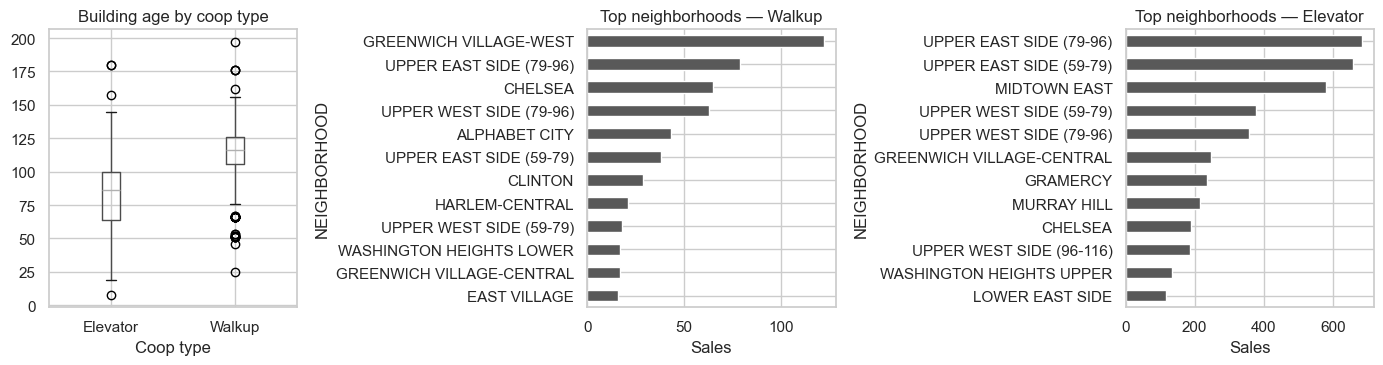

In [55]:
# Walkup vs elevator × location and vintage
top15 = n_by_nbhd.head(15).index
sub = coop_tp.loc[coop_tp["NEIGHBORHOOD"].isin(top15)]

type_loc = (
    sub.groupby(["NEIGHBORHOOD", "COOP_TYPE"], observed=True)["SALE PRICE"]
    .agg(n="count", median="median")
    .unstack("COOP_TYPE")
)
print("Top 15 neighborhoods: sale counts and medians by coop type (columns = type)")
print(type_loc.to_string())

age_by_type = coop_tp.dropna(subset=["BUILDING_AGE"]).groupby("COOP_TYPE")["BUILDING_AGE"]
print("\nBuilding age (years) by coop type:")
print(age_by_type.describe().to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

coop_tp.loc[coop_tp["COOP_TYPE"] != "Other"].dropna(subset=["BUILDING_AGE"]).boxplot(
    column="BUILDING_AGE", by="COOP_TYPE", ax=axes[0]
)
axes[0].set_title("Building age by coop type")
axes[0].set_xlabel("Coop type")
plt.suptitle("")

for ax, ct in zip(axes[1:], ["Walkup", "Elevator"]):
    g = coop_tp.loc[coop_tp["COOP_TYPE"] == ct]
    g["NEIGHBORHOOD"].value_counts().head(12).sort_values().plot(kind="barh", ax=ax, color="0.35")
    ax.set_title(f"Top neighborhoods — {ct}")
    ax.set_xlabel("Sales")

plt.tight_layout()
plt.show()
